In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d, griddata
from itertools import product
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
import glob

defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution
pd.set_option('display.max_rows', 200)

In [2]:
cmsCutflow = pd.read_pickle('../../CMS-EXO-20-004/AuxInfo/CMS-EXO-20-004-data/DMsimp_S3D_uR_CF_Monojet.pcl')

In [3]:
cutflow = pd.read_pickle('../../DMSimp_S3D_uR_2j-full_CMS_BPs/Events/run_01/scanResults_S3D_uR_2j-full_CMS_BPs.pcl')

In [4]:
cutflow.T

,0,1,2,3,4,5,6,7,8,9,...,134,135,136,137,138,139,140,141,142,143
Coupling,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,...,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel
Mode,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,...,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets
$m_{med}$,100.0,100.0,100.0,100.0,100.0,100.0,300.0,300.0,300.0,300.0,...,2000.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0
$m_{DM}$,1.0,1.0,1.0,75.0,75.0,75.0,1.0,1.0,1.0,200.0,...,500.0,1.0,1.0,1.0,200.0,200.0,200.0,350.0,350.0,350.0
Data-takingperiod,2018,2017,2016,2018,2017,2016,2018,2017,2016,2018,...,2016,2018,2017,2016,2018,2017,2016,2018,2017,2016
Luminosity (1/fb),59.7,41.5,36.0,59.7,41.5,36.0,59.7,41.5,36.0,59.7,...,36.0,59.7,41.5,36.0,59.7,41.5,36.0,59.7,41.5,36.0
bin_250.0_280.0,31011.509649,39871.940978,22151.078321,37722.603525,28846.696813,33284.650169,15224.747707,13694.072893,11466.394368,3213.375773,...,0.001203,0.000533,0.000526,0.000422,0.000675,0.000513,0.000474,0.00061,0.000539,0.000389
bin_250.0_280.0_ErrorPlus,8288.174582,9397.906615,7004.786012,9149.075224,8000.634191,8594.059719,456.149821,432.612212,395.863896,210.064946,...,0.000159,0.000061,0.000061,0.000054,0.000067,0.000058,0.000057,0.000067,0.000062,0.000051
bin_250.0_280.0_ErrorMinus,8288.174582,9397.906615,7004.786012,9149.075224,8000.634191,8594.059719,456.149821,432.612212,395.863896,210.064946,...,0.000159,0.000061,0.000061,0.000054,0.000067,0.000058,0.000057,0.000067,0.000062,0.000051
bin_280.0_310.0,19935.970489,15505.754825,17720.862657,19970.790102,26627.720135,13313.860068,9853.719117,8965.381055,7298.038847,1949.997264,...,0.00233,0.000585,0.000513,0.000578,0.000766,0.000616,0.000526,0.000721,0.000584,0.000552


In [5]:
cmsCutflow.T

,0,1,2,3,4,5,6,7,8,9,...,171,172,173,174,175,176,177,178,179,180
$m_{med}$,1000.0,300.0,1000.0,1800.0,1000.0,1000.0,1800.0,1400.0,1400.0,1400.0,...,1800.0,300.0,1200.0,1600.0,1000.0,1200.0,2000.0,1600.0,1200.0,1200.0
$m_{DM}$,400.0,1.0,400.0,1.0,600.0,600.0,1.0,1.0,200.0,1.0,...,1.0,200.0,750.0,500.0,1.0,1.0,500.0,800.0,900.0,750.0
$\lambda$,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Mode,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+QCDjets,DM+2QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+2QCDjets,...,DM+QCDjets,DM+QCDjets,DM+2QCDjets,DM+2QCDjets,DM+QCDjets,DM+QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets
Data-takingperiod,2017,2017,2018,2017,2017,2017,2018,2018,2017,2018,...,2017,2017,2018,2017,2018,2018,2018,2018,2017,2017
Fullsample,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Triggeremulation,0.90814,0.5588,0.90293,0.79897,0.93701,0.89098,0.98727,0.97933,0.98015,0.84539,...,0.9875,0.51669,0.89866,0.89838,0.96315,0.97395,0.84466,0.91676,0.86735,0.90544
$p_{T}^{miss}>250$GeV,0.72881,0.16807,0.72742,0.59405,0.77029,0.65109,0.95136,0.92475,0.92408,0.69336,...,0.95202,0.096462,0.70554,0.75958,0.86484,0.90216,0.68149,0.79855,0.58777,0.70809
$p_{T}^{miss}$qualityfilters,0.72671,0.16768,0.72562,0.59091,0.76717,0.64939,0.94169,0.91721,0.91589,0.69071,...,0.94073,0.096312,0.70405,0.75624,0.86041,0.89633,0.67874,0.79572,0.58629,0.70639
Electronveto,0.72431,0.1672,0.72357,0.58882,0.76191,0.64746,0.93593,0.91134,0.90961,0.68863,...,0.93456,0.09546,0.70199,0.7535,0.85541,0.89079,0.67642,0.79316,0.58398,0.70373


In [6]:
year = 2017

cutflow = cutflow[cutflow['Data-takingperiod']==year]
cmsCutflow = cmsCutflow[(cmsCutflow['Data-takingperiod']==year)&(cmsCutflow['Mode']=='DM+2QCDjets')]


In [7]:
models = []
mCols = ['$m_{med}$','$m_{DM}$','$\lambda$','Data-takingperiod']
for row in cutflow[mCols].values:
    m = dict(zip(mCols,row.tolist()))
    if m not in models:
        models.append(m)
print('%i models loaded' %len(models))

48 models loaded


In [8]:
parameters = {label : list(set([m[label] for m in models])) for label in mCols}
for k,v in parameters.items():
    if len(v) == 1:
        parameters[k] = v[0]
print(parameters)

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in parameters.items() if k not in ['$m_{med}$','$m_{DM}$']])
print(textstr)

{'$m_{med}$': [1600.0, 100.0, 1000.0, 1800.0, 300.0, 750.0, 1200.0, 2000.0, 500.0, 1400.0, 2200.0], '$m_{DM}$': [800.0, 1.0, 900.0, 550.0, 200.0, 650.0, 75.0, 750.0, 400.0, 500.0, 600.0, 700.0, 350.0], '$\\lambda$': 1.0, 'Data-takingperiod': 2017.0}
$\lambda$ = 1.0
Data-takingperiod = 2017.0


In [9]:
keys = list(cmsCutflow[mCols].columns.values)
i1 = cutflow.set_index(keys).index
i2 = cmsCutflow.set_index(keys).index
cutflow = cutflow[i1.isin(i2)]
cmsCutflow = cmsCutflow[i2.isin(i1)]
print(len(cutflow),len(cmsCutflow))

46 46


In [10]:
cutflow.sort_values(['$m_{med}$','$m_{DM}$'],inplace=True,
                ascending=[True,True],ignore_index=True)  
cmsCutflow.sort_values(['$m_{med}$','$m_{DM}$'],inplace=True,
                ascending=[True,True],ignore_index=True)

In [11]:
cutflow.T

,0,1,2,3,4,5,6,7,8,9,...,36,37,38,39,40,41,42,43,44,45
Coupling,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,...,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel
Mode,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,...,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets
$m_{med}$,100.0,100.0,300.0,300.0,500.0,500.0,500.0,750.0,750.0,750.0,...,1800.0,1800.0,1800.0,1800.0,1800.0,2000.0,2000.0,2000.0,2200.0,2200.0
$m_{DM}$,1.0,75.0,1.0,200.0,1.0,200.0,400.0,1.0,200.0,400.0,...,1.0,200.0,350.0,500.0,650.0,1.0,350.0,500.0,1.0,200.0
Data-takingperiod,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,...,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017
Luminosity (1/fb),41.5,41.5,41.5,41.5,41.5,41.5,41.5,41.5,41.5,41.5,...,41.5,41.5,41.5,41.5,41.5,41.5,41.5,41.5,41.5,41.5
bin_250.0_280.0,39871.940978,28846.696813,13694.072893,2773.93977,721.451211,888.005995,273.439546,35.49621,43.018573,61.188746,...,0.006283,0.007578,0.007905,0.00805,0.009134,0.001675,0.002185,0.001929,0.000526,0.000513
bin_250.0_280.0_ErrorPlus,9397.906615,8000.634191,432.612212,195.173721,24.716511,27.40446,15.23819,1.568726,1.727659,2.061496,...,0.000613,0.000677,0.00068,0.0007,0.000738,0.000184,0.000208,0.000198,0.000061,0.000058
bin_250.0_280.0_ErrorMinus,9397.906615,8000.634191,432.612212,195.173721,24.716511,27.40446,15.23819,1.568726,1.727659,2.061496,...,0.000613,0.000677,0.00068,0.0007,0.000738,0.000184,0.000208,0.000198,0.000061,0.000058
bin_280.0_310.0,15505.754825,26627.720135,8965.381055,2114.785765,712.983474,832.188475,227.583225,36.120167,43.571867,57.377442,...,0.006811,0.008165,0.009545,0.00945,0.011345,0.001944,0.002262,0.002559,0.000513,0.000616


In [12]:
cmsCutflow.T

,0,1,2,3,4,5,6,7,8,9,...,36,37,38,39,40,41,42,43,44,45
$m_{med}$,100.0,100.0,300.0,300.0,500.0,500.0,500.0,750.0,750.0,750.0,...,1800.0,1800.0,1800.0,1800.0,1800.0,2000.0,2000.0,2000.0,2200.0,2200.0
$m_{DM}$,1.0,75.0,1.0,200.0,1.0,200.0,400.0,1.0,200.0,400.0,...,1.0,200.0,350.0,500.0,650.0,1.0,350.0,500.0,1.0,200.0
$\lambda$,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Mode,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,...,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets
Data-takingperiod,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,...,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017
Fullsample,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Triggeremulation,0.12259,0.22066,0.5588,0.60136,0.78855,0.7855,0.65513,0.86881,0.88265,0.85896,...,0.79897,0.82011,0.85555,0.87751,0.89749,0.78041,0.83202,0.85823,0.74639,0.77777
$p_{T}^{miss}>250$GeV,0.028567,0.075977,0.16807,0.21455,0.39512,0.39029,0.2787,0.62345,0.63913,0.55841,...,0.59405,0.60917,0.67584,0.72289,0.76014,0.56533,0.62899,0.6819,0.50435,0.52241
$p_{T}^{miss}$qualityfilters,0.028531,0.075829,0.16768,0.21423,0.39447,0.38955,0.27808,0.62203,0.63786,0.55747,...,0.59091,0.60639,0.67249,0.71939,0.75595,0.56199,0.62604,0.6783,0.50158,0.52016
Electronveto,0.028406,0.075346,0.1672,0.21355,0.39346,0.38846,0.27688,0.62023,0.63609,0.55559,...,0.58882,0.604,0.67052,0.71664,0.75347,0.56005,0.62401,0.67584,0.49979,0.51868


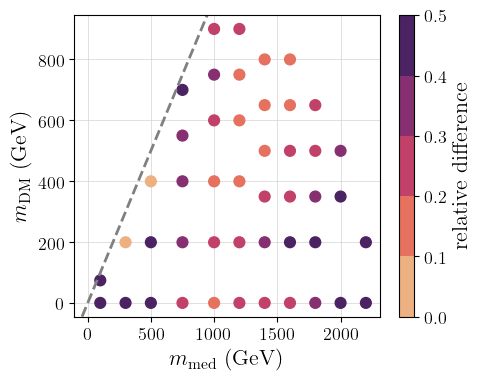

In [13]:
mmed = cutflow['$m_{med}$']
mDM = cutflow['$m_{DM}$']

relDiff = np.abs(cmsCutflow['HCALmitigation($\\phi^{miss}$)'] - cutflow['HCALmitigation($\\phi^{miss}$)'])/np.array(cmsCutflow['HCALmitigation($\\phi^{miss}$)'])

plt.scatter(x=mmed, y=mDM, c=relDiff, cmap=plt.get_cmap('flare', 5), vmin=0., vmax=0.5, s=60)
cbar = plt.colorbar(label=r'relative difference')
cbar.set_ticks([0.,0.1,0.2,0.3,0.4,0.5])
plt.axline((1, 1), slope=1, linestyle='--', color='gray')

plt.xlabel(r'$m_{\rm med}$ (GeV)')
plt.ylabel(r'$m_{\rm DM}$ (GeV)')

plt.tight_layout()


plt.show()

In [39]:
cutflow[(cutflow['$m_{med}$']==1000)&(cutflow['$m_{DM}$']==900)].T

,17
Coupling,tchannel
Mode,DM+QCDjets
$m_{med}$,1000.0
$m_{DM}$,900.0
Data-takingperiod,2017
Luminosity (1/fb),41.5
bin_250.0_280.0,7.086368
bin_250.0_280.0_ErrorPlus,0.254059
bin_250.0_280.0_ErrorMinus,0.254059
bin_280.0_310.0,6.02068


In [41]:
cmsCutflow[(cutflow['$m_{med}$']==100)&(cutflow['$m_{DM}$']==1)].T

,0
$m_{med}$,100.0
$m_{DM}$,1.0
$\lambda$,1.0
Mode,DM+QCDjets
Data-takingperiod,2017
Fullsample,1.0
Triggeremulation,0.047334
$p_{T}^{miss}>250$GeV,0.003092
$p_{T}^{miss}$qualityfilters,0.003092
Electronveto,0.003073


In [18]:
cutflow[(cutflow['$m_{med}$']==1800)&(cutflow['$m_{DM}$']==1)].T

,36
Coupling,tchannel
Mode,DM+QCDjets
$m_{med}$,1800.0
$m_{DM}$,1.0
Data-takingperiod,2017
Luminosity (1/fb),41.5
bin_250.0_280.0,7.812074
bin_250.0_280.0_ErrorPlus,0.36424
bin_250.0_280.0_ErrorMinus,0.36424
bin_280.0_310.0,6.470435
